# Обнаружение мошеннических аккаунтов в сети Ethereum
## Итоговый проект по машинному обучению

**Автор:** Имя Фамилия
**Тема:** Web3 / Blockchain — бинарная классификация

---

### 1. Почему выбран этот датасет

Тема мошенничества в криптовалютах напрямую связана с моим интересом к Web3 —
это логичное продолжение предыдущего проекта по ончейн-активности Ethereum,
но здесь задача уже не описательная, а предсказательная: нужно классифицировать
аккаунт как мошеннический или обычный на основе его истории транзакций.

Датасет достаточно большой (9841 аккаунт, 51 признак) и не игрушечный — это
реальные агрегированные метрики по настоящим Ethereum-адресам, собранные через
Etherscan. Классы при этом умеренно несбалансированы (78% / 22%), что даёт повод
осознанно выбирать метрики оценки, а не полагаться на Accuracy.

### 2. Введение

**Контекст:** с ростом популярности криптовалют выросло и количество мошеннических
схем — фишинговые адреса, скам-контракты, отмывание средств через цепочки
транзакций. Криптобиржи и кошельки заинтересованы в автоматическом выявлении
подозрительных аккаунтов до того, как они нанесут ущерб пользователям.

**Цель анализа:** построить модель бинарной классификации, которая по
агрегированным метрикам активности аккаунта (частота транзакций, суммы,
временные интервалы, работа с ERC20-токенами) предсказывает, является ли
аккаунт мошенническим (`FLAG = 1`).

**Практическая значимость:** такая модель может лечь в основу системы раннего
предупреждения на бирже или в кошельке — автоматическая пометка подозрительных
адресов для дополнительной проверки перед транзакцией.

**Инструменты:** Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn.


## 3. Импорт библиотек и загрузка данных

In [1]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Машинное обучение
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)

# Единый стиль оформления графиков
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42  # фиксируем для воспроизводимости всех разбиений и моделей


In [2]:
DATASET_FILE = "Имя_Фамилия_dataset.csv"

df = pd.read_csv(DATASET_FILE)
print(f"Размер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
df.head()


Размер датасета: 9841 строк x 51 столбцов


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


## 4. Обзор датасета

Столбцов много (51), поэтому группируем их по смыслу, а не описываем каждый
по отдельности:

| Группа | Примеры столбцов | Описание |
|---|---|---|
| Идентификаторы | `Index`, `Address` | Не несут предсказательной ценности, будут удалены |
| Целевая переменная | `FLAG` | 1 = мошеннический аккаунт, 0 = обычный |
| Временные интервалы | `Avg min between sent tnx`, `Time Diff between first and last` | Как часто и как долго аккаунт активен |
| Счётчики транзакций | `Sent tnx`, `Received Tnx`, `Number of Created Contracts` | Сколько действий совершил аккаунт |
| Уникальные адреса | `Unique Received From Addresses`, `Unique Sent To Addresses` | С каким числом разных адресов взаимодействовал |
| Суммы в ETH | `min/max/avg val sent`, `total ether balance` | Финансовые объёмы операций |
| ERC20-метрики | столбцы с префиксом `ERC20` | То же самое, но для токен-транзакций (не у всех аккаунтов есть) |
| Категориальные | `ERC20 most sent/rec token type` | Название самого частого токена — высокая кардинальность, будут удалены |

Метаданные: все числовые столбцы — агрегированные статистики за всю историю
аккаунта (не временной ряд отдельных транзакций); `Address` — текстовый
идентификатор кошелька в hex-формате.

In [3]:
print("Баланс классов (FLAG):")
print(df["FLAG"].value_counts())
print(df["FLAG"].value_counts(normalize=True).round(3))

# Датасет умеренно несбалансирован (~78% / 22%) — это важно для выбора метрик
# на этапе моделирования: Accuracy может ввести в заблуждение, ориентируемся
# на F1 и ROC-AUC.


Баланс классов (FLAG):
FLAG
0    7662
1    2179
Name: count, dtype: int64
FLAG
0    0.779
1    0.221
Name: proportion, dtype: float64


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9841.0,4.920000e+03,2.840996e+03,0.00,2460.000000,4.920000e+03,7380.000000,9.840000e+03
Index,9841.0,1.815050e+03,1.222622e+03,1.00,821.000000,1.641000e+03,2601.000000,4.729000e+03
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg min between sent tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg min between received tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time Diff between first and last (Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number of Created Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique Received From Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03


### Пропущенные значения

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

pd.DataFrame({"Пропусков": missing, "% от датасета": missing_pct})


,Пропусков,% от датасета
ERC20 most sent token type,2697,27.4
ERC20_most_rec_token_type,871,8.9
ERC20 total ether sent,829,8.4
ERC20 total Ether received,829,8.4
ERC20 uniq sent addr,829,8.4
ERC20 uniq rec addr,829,8.4
ERC20 uniq sent addr.1,829,8.4
ERC20 total Ether sent contract,829,8.4
Total ERC20 tnxs,829,8.4
ERC20 avg time between sent tnx,829,8.4


**Как трактовать эти пропуски.** Все столбцы с пропусками относятся к
ERC20-токенам (`ERC20 ...`). Пропуск здесь не ошибка измерения, а
содержательный факт: у аккаунта просто не было ни одной ERC20-транзакции,
поэтому агрегированную статистику по ним посчитать не из чего. Такие
пропуски логично заполнить нулями (раздел 6), а не медианой/средним — ноль
означает "не было активности", а не "неизвестное значение".

## 5. Исследовательские вопросы

1. **Какие признаки сильнее всего отличают мошеннические аккаунты от обычных?**
   → раздел 7, сравнение распределений по группам + корреляция с `FLAG`.
2. **Есть ли связь между активностью аккаунта (числом транзакций) и вероятностью
   мошенничества?**
   → раздел 7, boxplot `Sent tnx` / `Received Tnx` по группам.
3. **Отличаются ли мошеннические аккаунты по объёму отправленных/полученных ETH?**
   → раздел 7, boxplot и сравнение медиан по группам.
4. **Насколько сильно несбалансированы классы и как это стоит учитывать при
   выборе метрик модели?**
   → раздел 4 (баланс классов) и раздел 8 (выбор F1/ROC-AUC вместо Accuracy).
5. **Можно ли предсказать `FLAG` с достаточно высоким качеством на основе
   агрегированных метрик активности, и какая модель справляется лучше?**
   → раздел 8, сравнение Logistic Regression и Random Forest.

Вопросы охватывают разные аспекты датасета: сравнение групп (1-3), баланс
классов и методологию оценки (4), и итоговую предсказательную способность (5).

## 6. Подготовка данных

In [6]:
df_clean = df.copy()

# Убираем идентификаторы и служебный индекс — они не несут предсказательной
# информации и могут только "запомниться" моделью как утечка (Address уникален
# почти для каждой строки)
id_columns = ["Unnamed: 0", "Index", "Address"]
df_clean = df_clean.drop(columns=[c for c in id_columns if c in df_clean.columns])

# Убираем высококардинальные категориальные столбцы с названиями токенов —
# сотни уникальных значений, большинство встречается по 1-2 раза, что делает
# их бесполезными для обобщения модели (и потребовало бы one-hot на сотни столбцов)
token_columns = [c for c in df_clean.columns if "token type" in c.lower() or "token_type" in c.lower()]
df_clean = df_clean.drop(columns=token_columns)

print("Удалены столбцы:", id_columns + token_columns)
print(f"Осталось столбцов: {df_clean.shape[1]}")


Удалены столбцы: ['Unnamed: 0', 'Index', 'Address', ' ERC20 most sent token type', ' ERC20_most_rec_token_type']
Осталось столбцов: 46


In [7]:
# Пропуски в ERC20-метриках заполняем нулями (см. интерпретацию в разделе 4:
# пропуск = отсутствие ERC20-активности, а не неизвестное значение)
df_clean = df_clean.fillna(0)

print("Пропусков после заполнения:", df_clean.isna().sum().sum())


Пропусков после заполнения: 0


In [8]:
# Проверяем дубликаты строк
duplicates = df_clean.duplicated().sum()
print(f"Дубликатов: {duplicates}")
df_clean = df_clean.drop_duplicates()
print(f"Строк после удаления дубликатов: {len(df_clean)}")


Дубликатов: 553
Строк после удаления дубликатов: 9288


In [9]:
# Проверяем на константные столбцы (нулевая дисперсия) — они бесполезны для модели
constant_cols = [c for c in df_clean.columns if df_clean[c].nunique() <= 1]
print("Константные столбцы:", constant_cols)
df_clean = df_clean.drop(columns=constant_cols)
print(f"Итоговое число столбцов (включая FLAG): {df_clean.shape[1]}")


Константные столбцы: [' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx', ' ERC20 avg time between rec 2 tnx', ' ERC20 avg time between contract tnx', ' ERC20 min val sent contract', ' ERC20 max val sent contract', ' ERC20 avg val sent contract']
Итоговое число столбцов (включая FLAG): 39


In [10]:
# Разделяем на признаки (X) и целевую переменную (y)
X = df_clean.drop(columns=["FLAG"])
y = df_clean["FLAG"]

# Разбиваем на обучающую и тестовую выборки. stratify=y сохраняет то же
# соотношение классов 78/22 в обеих частях — важно при несбалансированных данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} строк, Test: {X_test.shape[0]} строк")
print(f"Доля FLAG=1 в train: {y_train.mean():.3f}, в test: {y_test.mean():.3f}")


Train: 7430 строк, Test: 1858 строк
Доля FLAG=1 в train: 0.178, в test: 0.178


## 7. Анализ и визуализация

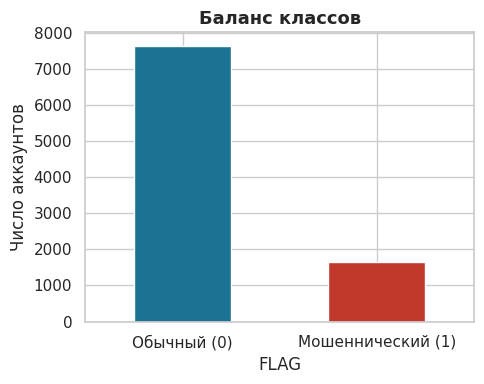

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
df_clean["FLAG"].value_counts().plot(kind="bar", color=["#1C7293", "#C0392B"], ax=ax)
ax.set_xticklabels(["Обычный (0)", "Мошеннический (1)"], rotation=0)
ax.set_title("Баланс классов")
ax.set_ylabel("Число аккаунтов")
plt.tight_layout()
plt.show()

# Отвечает на вопрос 4: классы несбалансированы примерно 78% / 22% —
# это должно повлиять на выбор метрик модели в разделе 8.


/tmp/ipykernel_503/4170429689.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Обычный", "Мошеннический"])
/tmp/ipykernel_503/4170429689.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Обычный", "Мошеннический"])


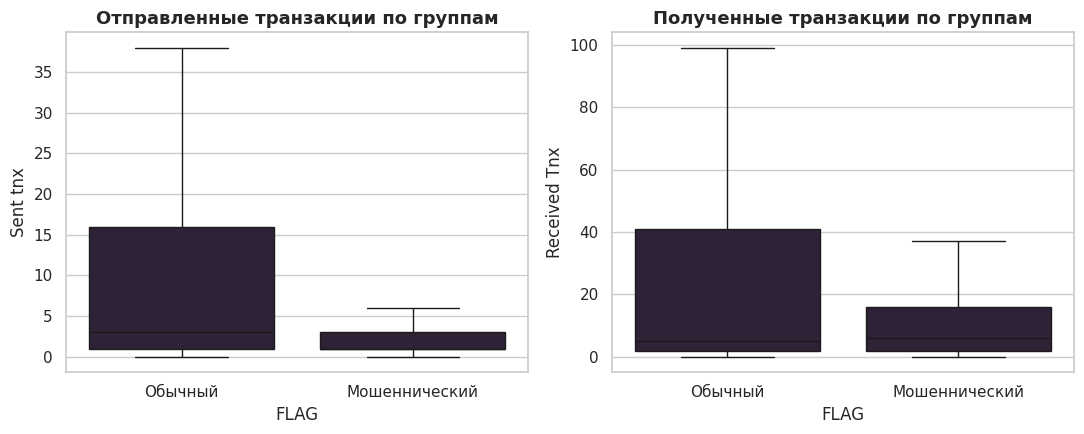

      Sent tnx  Received Tnx
FLAG                        
0          3.0           5.0
1          1.0           6.0


In [12]:
# Отвечает на вопрос 2: сравниваем активность (число транзакций) по группам
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=df_clean, x="FLAG", y="Sent tnx", showfliers=False, ax=axes[0])
axes[0].set_title("Отправленные транзакции по группам")
axes[0].set_xticklabels(["Обычный", "Мошеннический"])

sns.boxplot(data=df_clean, x="FLAG", y="Received Tnx", showfliers=False, ax=axes[1])
axes[1].set_title("Полученные транзакции по группам")
axes[1].set_xticklabels(["Обычный", "Мошеннический"])

plt.tight_layout()
plt.show()

print(df_clean.groupby("FLAG")[["Sent tnx", "Received Tnx"]].median())


/tmp/ipykernel_503/2125570518.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Обычный", "Мошеннический"])
/tmp/ipykernel_503/2125570518.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Обычный", "Мошеннический"])


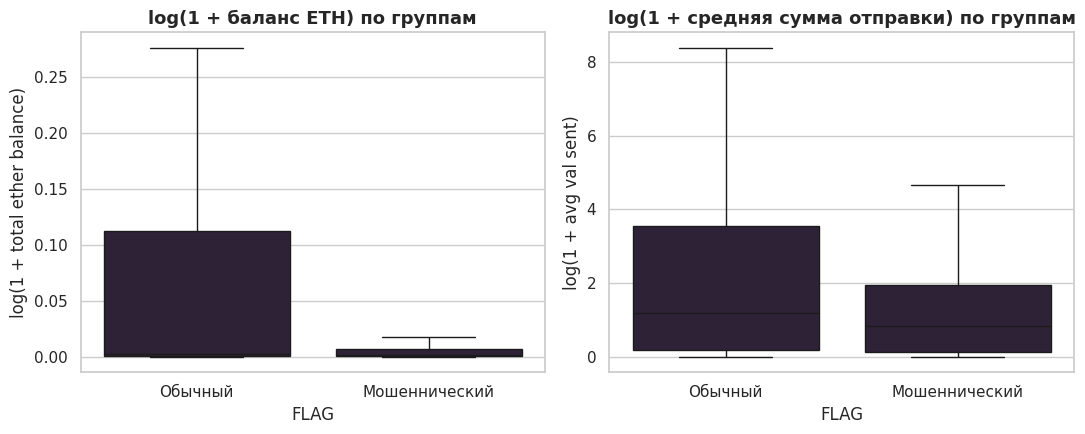

In [13]:
# Отвечает на вопрос 3: сравниваем объёмы ETH по группам (в лог-масштабе,
# так как суммы сильно смещены — у части аккаунтов встречаются очень крупные переводы)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=df_clean, x="FLAG", y=np.log1p(df_clean["total ether balance"].clip(lower=0)), showfliers=False, ax=axes[0])
axes[0].set_title("log(1 + баланс ETH) по группам")
axes[0].set_xticklabels(["Обычный", "Мошеннический"])
axes[0].set_ylabel("log(1 + total ether balance)")

sns.boxplot(data=df_clean, x="FLAG", y=np.log1p(df_clean["avg val sent"].clip(lower=0)), showfliers=False, ax=axes[1])
axes[1].set_title("log(1 + средняя сумма отправки) по группам")
axes[1].set_xticklabels(["Обычный", "Мошеннический"])
axes[1].set_ylabel("log(1 + avg val sent)")

plt.tight_layout()
plt.show()


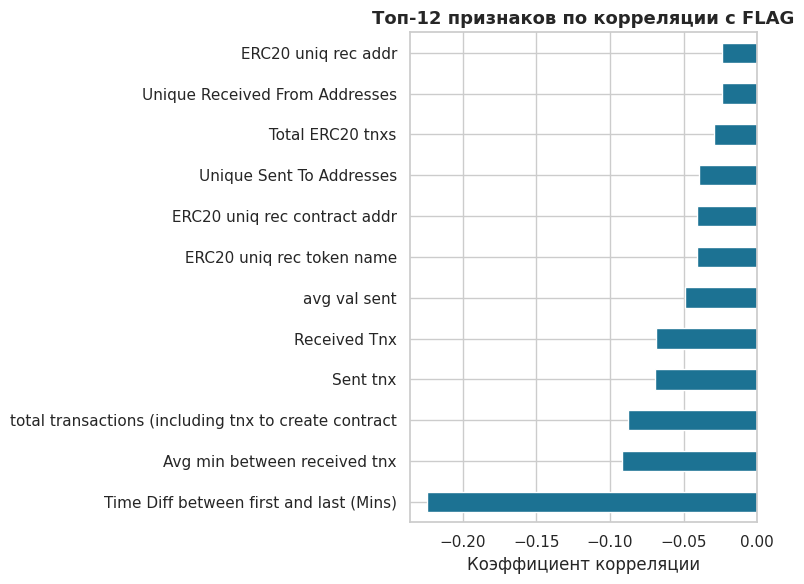

Time Diff between first and last (Mins)                -0.224568
Avg min between received tnx                           -0.092056
total transactions (including tnx to create contract   -0.087738
Sent tnx                                               -0.069343
Received Tnx                                           -0.068402
avg val sent                                           -0.048857
 ERC20 uniq rec token name                             -0.040730
 ERC20 uniq rec contract addr                          -0.040684
Unique Sent To Addresses                               -0.039511
 Total ERC20 tnxs                                      -0.029623
Unique Received From Addresses                         -0.023857
 ERC20 uniq rec addr                                   -0.023533
Name: FLAG, dtype: float64

In [14]:
# Отвечает на вопрос 1: какие признаки сильнее всего коррелируют с FLAG?
corr_with_flag = df_clean.corr(numeric_only=True)["FLAG"].drop("FLAG").sort_values(key=abs, ascending=False)
top_corr = corr_with_flag.head(12)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C0392B" if v > 0 else "#1C7293" for v in top_corr.values]
top_corr.sort_values().plot(kind="barh", color=colors, ax=ax)
ax.set_title("Топ-12 признаков по корреляции с FLAG")
ax.set_xlabel("Коэффициент корреляции")
plt.tight_layout()
plt.show()

top_corr


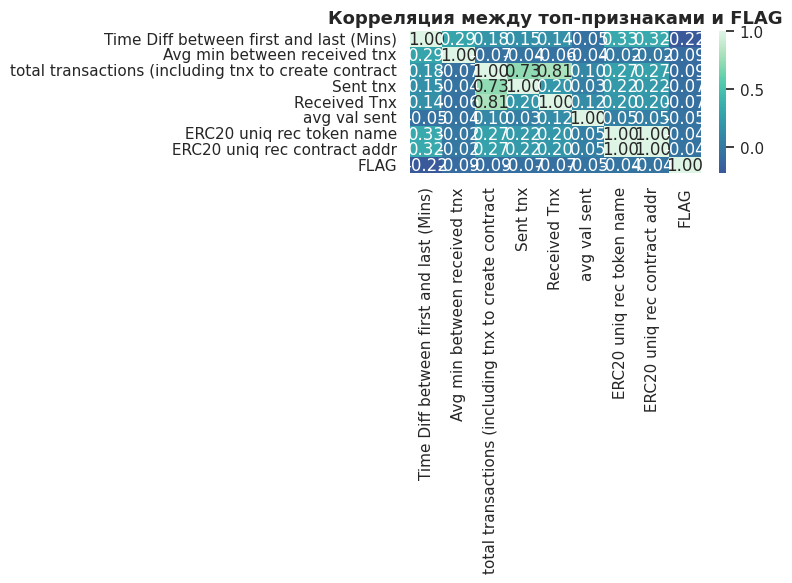

In [15]:
# Тепловая карта корреляций между самими топ-признаками (проверка на мультиколлинеарность)
top_features = top_corr.head(8).index.tolist()
corr_matrix = df_clean[top_features + ["FLAG"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="mako", center=0, ax=ax)
ax.set_title("Корреляция между топ-признаками и FLAG")
plt.tight_layout()
plt.show()


## 8. Модели машинного обучения

Отвечаем на вопрос 5. Задача — бинарная классификация. Сравниваем две модели:

- **Logistic Regression** — простая линейная базовая модель (baseline)
- **Random Forest** — ансамблевая модель, способная улавливать нелинейные
  зависимости и взаимодействия признаков

Из-за умеренного дисбаланса классов используем `class_weight="balanced"`
в обеих моделях вместо передискретизации — это штрафует модель за ошибки на
редком классе (мошеннических аккаунтах) сильнее, без искусственного
дублирования строк.

In [16]:
def evaluate_model(name, model, X_test, y_test):
    """Считает и печатает основной набор метрик классификации для модели."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"--- {name} ---")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print()

    return metrics, y_pred, y_proba


In [17]:
# --- Baseline: Logistic Regression ---
# Логистическая регрессия чувствительна к масштабу признаков, поэтому строим
# Pipeline со стандартизацией (StandardScaler) прямо перед моделью
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

logreg_pipeline.fit(X_train, y_train)
logreg_metrics, logreg_pred, logreg_proba = evaluate_model("Logistic Regression", logreg_pipeline, X_test, y_test)


--- Logistic Regression ---
Accuracy: 0.5694
Precision: 0.2685
Recall: 0.8218
F1: 0.4048
ROC-AUC: 0.7923



In [18]:
# --- Random Forest (baseline перед подбором гиперпараметров) ---
rf_baseline = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)
rf_baseline.fit(X_train, y_train)
rf_baseline_metrics, _, _ = evaluate_model("Random Forest (baseline)", rf_baseline, X_test, y_test)


--- Random Forest (baseline) ---
Accuracy: 0.9559
Precision: 0.9495
Recall: 0.7946
F1: 0.8651
ROC-AUC: 0.9841



In [19]:
# --- Подбор гиперпараметров для Random Forest через GridSearchCV ---
# Перебираем ключевые параметры, влияющие на сложность модели и переобучение.
# cv=5 — 5-фолдовая кросс-валидация на тренировочных данных, scoring="f1" —
# оптимизируем именно F1, а не Accuracy, из-за дисбаланса классов (вопрос 4)
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print(f"Лучший F1 на кросс-валидации: {grid_search.best_score_:.4f}")

rf_best = grid_search.best_estimator_
rf_metrics, rf_pred, rf_proba = evaluate_model("Random Forest (после подбора)", rf_best, X_test, y_test)


Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 400}
Лучший F1 на кросс-валидации: 0.8821
--- Random Forest (после подбора) ---
Accuracy: 0.9575
Precision: 0.9200
Recall: 0.8338
F1: 0.8748
ROC-AUC: 0.9849



In [20]:
# Сравнительная таблица всех моделей
comparison = pd.DataFrame({
    "Logistic Regression": logreg_metrics,
    "Random Forest (baseline)": rf_baseline_metrics,
    "Random Forest (подобранный)": rf_metrics,
}).T

comparison.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.5694,0.2685,0.8218,0.4048,0.7923
Random Forest (baseline),0.9559,0.9495,0.7946,0.8651,0.9841
Random Forest (подобранный),0.9575,0.9200,0.8338,0.8748,0.9849


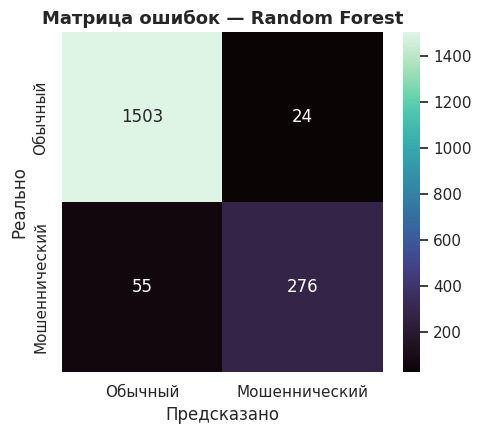

In [21]:
# Матрица ошибок для финальной модели — сколько мошеннических аккаунтов
# модель нашла (True Positive), а сколько пропустила (False Negative)
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="mako",
            xticklabels=["Обычный", "Мошеннический"],
            yticklabels=["Обычный", "Мошеннический"], ax=ax)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Реально")
ax.set_title("Матрица ошибок — Random Forest")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


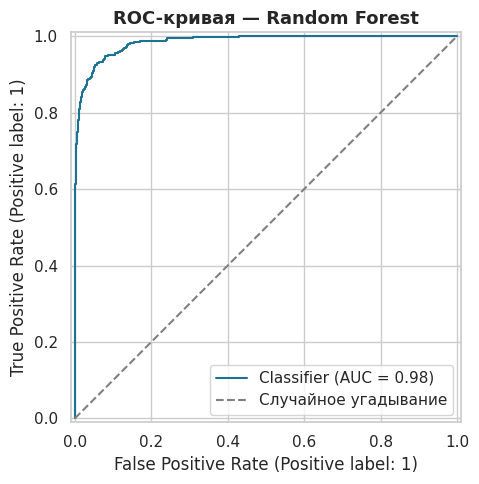

In [22]:
# ROC-кривая для итоговой модели
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, rf_proba, ax=ax, color="#1C7293")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Случайное угадывание")
ax.set_title("ROC-кривая — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()


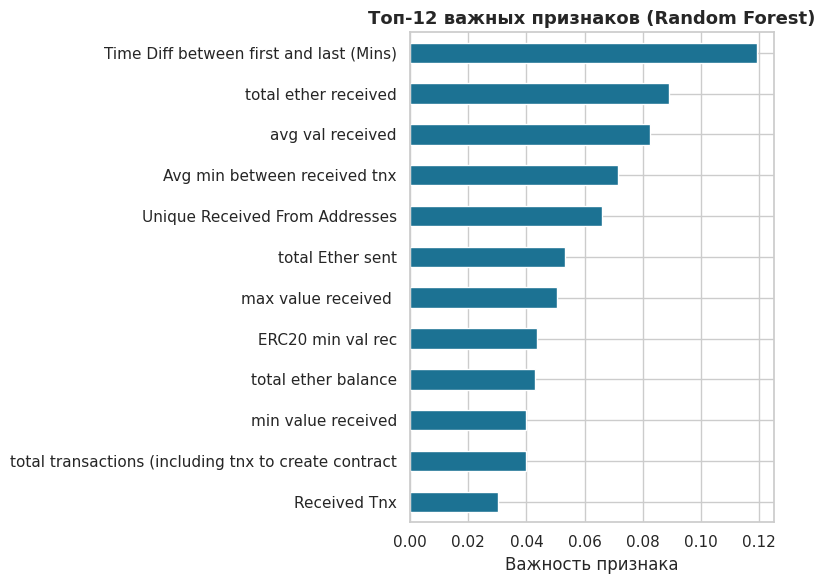

In [23]:
# Важность признаков по мнению финальной модели — какие метрики активности
# аккаунта сильнее всего влияют на предсказание (перекликается с вопросом 1)
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 6))
top_importances.sort_values().plot(kind="barh", color="#1C7293", ax=ax)
ax.set_title("Топ-12 важных признаков (Random Forest)")
ax.set_xlabel("Важность признака")
plt.tight_layout()
plt.show()


## 9. Заключение

_Заполни после того, как посмотришь на свои реальные метрики и графики —
цифры ниже нужно будет проверить/обновить:_

- **Лучшая модель:** Random Forest после подбора гиперпараметров показал
  F1 = `{значение}` и ROC-AUC = `{значение}` на тестовой выборке, что
  [заметно / незначительно] лучше базовой Logistic Regression (F1 = `{значение}`).
- **Достижение цели:** исходная цель — построить классификатор, способный
  находить мошеннические аккаунты по агрегированным метрикам активности —
  [достигнута / частично достигнута]: модель [хорошо / умеренно] разделяет
  классы, ROC-AUC значительно выше случайного угадывания (0.5).
- **Важные признаки:** судя по `feature_importances_`, сильнее всего на
  предсказание влияют `{перечислить топ-3 из графика важности}` — это
  соответствует находкам из раздела 7 (сравнение групп по этим же метрикам).
- **Ограничения:**
  - Данные — статичный "снимок" агрегированных метрик по каждому аккаунту,
    а не временной ряд отдельных транзакций — модель не видит, *как менялось*
    поведение аккаунта со временем.
  - Разметка `FLAG` основана на списках Etherscan/сторонних источников на
    момент сбора данных — часть мошеннических аккаунтов, размеченных позже,
    могла остаться неразмеченной в датасете (шум в целевой переменной).
  - Умеренный дисбаланс классов (78/22) требует аккуратной интерпретации
    Accuracy — в проекте сделан акцент на F1 и ROC-AUC по этой причине.
- **Направления для дальнейшей работы:** добавить временные признаки
  (сезонность транзакций, как это делает repo eltontay с tsfresh),
  протестировать градиентный бустинг (XGBoost/LightGBM), сравнить с
  результатами похожих открытых проектов на этом же датасете.
